# Operating Systems Project

## Team Members
- Ahmed Adel ElSawy                         2305238
- Moamen Mahmoud                            2305520
- Moataz Mahmoud                             2305238
- Mohab Ahmed                               2305238
- Member 5

---

# Project Overview

This project demonstrates the implementation and analysis of fundamental Operating System algorithms using Python.

The project focuses on three major areas:

1. CPU Scheduling
2. Memory Allocation
3. Page Replacement Algorithms

The algorithms implemented in this project are:

- CPU Scheduling: Round Robin
- Memory Allocation: Best Fit
- Page Replacement: LRU

All inputs are taken dynamically from the user without using hardcoded values.

The project also includes:
- Step-by-step execution
- Performance analysis
- Comparison with alternative algorithms
- Visualizations using graphs and tables

In [11]:
import matplotlib.pyplot as plt
from tabulate import tabulate

# Section 1: CPU Scheduling Algorithm

## Round Robin Scheduling

Round Robin is a CPU Scheduling algorithm designed for time-sharing systems.

In this algorithm:
- Each process is assigned a fixed time quantum.
- Processes are executed in a circular queue.
- If a process is not completed within its quantum, it is moved to the end of the queue.

## Advantages
- Fair allocation of CPU time
- Prevents starvation
- Suitable for multitasking systems

## Disadvantages
- High context switching overhead
- Performance depends heavily on time quantum selection

## Required Inputs
- Number of processes
- Arrival time for each process
- Burst time for each process
- Time quantum

## Expected Outputs
- Gantt Chart
- Waiting Time
- Turnaround Time
- Average Waiting Time
- Average Turnaround Time

In [12]:
# ROUND ROBIN INPUT

n = int(input("Enter number of processes: "))

processes = []

for i in range(n):
    arrival = int(input(f"Enter arrival time for P{i+1}: "))
    burst = int(input(f"Enter burst time for P{i+1}: "))
    
    processes.append({
        "pid": f"P{i+1}",
        "arrival": arrival,
        "burst": burst,
        "remaining": burst,
        "completion": 0
    })

quantum = int(input("Enter time quantum: "))

In [13]:
# ROUND ROBIN IMPLEMENTATION

time = 0
queue = []
completed = []
gantt = []

processes.sort(key=lambda x: x["arrival"])

i = 0

while len(completed) < n:

    while i < n and processes[i]["arrival"] <= time:
        queue.append(processes[i])
        i += 1

    if not queue:
        time += 1
        continue

    current = queue.pop(0)

    execute = min(quantum, current["remaining"])

    gantt.append((current["pid"], time, time + execute))

    time += execute

    current["remaining"] -= execute

    while i < n and processes[i]["arrival"] <= time:
        queue.append(processes[i])
        i += 1

    if current["remaining"] > 0:
        queue.append(current)
    else:
        current["completion"] = time
        completed.append(current)

In [14]:
# ROUND ROBIN RESULTS

results = []

total_waiting = 0
total_turnaround = 0

for p in processes:
    turnaround = p["completion"] - p["arrival"]
    waiting = turnaround - p["burst"]

    total_waiting += waiting
    total_turnaround += turnaround

    results.append([
        p["pid"],
        p["arrival"],
        p["burst"],
        p["completion"],
        waiting,
        turnaround
    ])

headers = [
    "Process",
    "Arrival",
    "Burst",
    "Completion",
    "Waiting",
    "Turnaround"
]

print(tabulate(results, headers=headers, tablefmt="grid"))

print("\nAverage Waiting Time:",
      total_waiting / n)

print("Average Turnaround Time:",
      total_turnaround / n)

+-----------+-----------+---------+--------------+-----------+--------------+
| Process   |   Arrival |   Burst |   Completion |   Waiting |   Turnaround |
+===========+===========+=========+==============+===========+==============+
| P1        |         0 |       3 |            5 |         2 |            5 |
+-----------+-----------+---------+--------------+-----------+--------------+
| P2        |         2 |       9 |           24 |        13 |           22 |
+-----------+-----------+---------+--------------+-----------+--------------+
| P3        |         4 |       2 |            7 |         1 |            3 |
+-----------+-----------+---------+--------------+-----------+--------------+
| P4        |         5 |       8 |           26 |        13 |           21 |
+-----------+-----------+---------+--------------+-----------+--------------+
| P5        |         7 |       4 |           19 |         8 |           12 |
+-----------+-----------+---------+--------------+-----------+--

In [15]:
# GANTT CHART

print("\nGantt Chart:\n")

for item in gantt:
    print(f"| {item[0]} ", end="")

print("|")

print(gantt[0][1], end="")

for item in gantt:
    print(f"    {item[2]}", end="")

print()


Gantt Chart:

| P1 | P2 | P1 | P3 | P2 | P4 | P5 | P2 | P4 | P5 | P2 | P4 | P2 | P4 |
0    2    4    5    7    9    11    13    15    17    19    21    23    24    26


# CPU Scheduling Analysis

## Comparison: Round Robin vs FCFS

| Feature | Round Robin | FCFS |
|---|---|---|
| Fairness | High | Low |
| Starvation | No | Possible |
| Context Switching | High | Low |
| Response Time | Better | Poor |
| Suitable For | Time-sharing systems | Batch systems |

## Analysis

Round Robin provides better responsiveness compared to FCFS because every process gets CPU time periodically.

However, Round Robin may introduce excessive context switching if the time quantum is very small.

# Section 2: Memory Allocation Algorithm

## Best Fit Memory Allocation

Best Fit allocates the smallest available memory block that can fit the process.

## Advantages
- Reduces wasted memory space

## Disadvantages
- May create many small unusable fragments

## Required Inputs
- Number of memory blocks
- Size of each memory block
- Number of processes
- Size of each process

## Expected Outputs
- Allocation results
- Fragmentation analysis

In [16]:
# BEST FIT INPUT

num_blocks = int(input("Enter number of memory blocks: "))

blocks = []

for i in range(num_blocks):
    size = int(input(f"Enter size of Block {i+1}: "))
    blocks.append(size)

num_processes = int(input("Enter number of processes: "))

process_sizes = []

for i in range(num_processes):
    size = int(input(f"Enter size of Process {i+1}: "))
    process_sizes.append(size)

In [17]:
# BEST FIT IMPLEMENTATION

allocation = [-1] * num_processes

remaining_blocks = blocks.copy()

for i in range(num_processes):

    best_idx = -1

    for j in range(num_blocks):

        if remaining_blocks[j] >= process_sizes[i]:

            if best_idx == -1 or remaining_blocks[j] < remaining_blocks[best_idx]:
                best_idx = j

    if best_idx != -1:
        allocation[i] = best_idx
        remaining_blocks[best_idx] -= process_sizes[i]

In [18]:
# BEST FIT RESULTS

table = []

for i in range(num_processes):

    if allocation[i] != -1:
        status = f"Block {allocation[i]+1}"
    else:
        status = "Not Allocated"

    table.append([
        f"P{i+1}",
        process_sizes[i],
        status
    ])

print(tabulate(
    table,
    headers=["Process", "Size", "Allocation"],
    tablefmt="grid"
))

print("\nRemaining Block Sizes:")

for i in range(num_blocks):
    print(f"Block {i+1}: {remaining_blocks[i]}")

+-----------+--------+--------------+
| Process   |   Size | Allocation   |
+===========+========+==============+
| P1        |      2 | Block 1      |
+-----------+--------+--------------+
| P2        |      4 | Block 2      |
+-----------+--------+--------------+
| P3        |      6 | Block 3      |
+-----------+--------+--------------+
| P4        |      6 | Block 4      |
+-----------+--------+--------------+

Remaining Block Sizes:
Block 1: 0
Block 2: 0
Block 3: 0
Block 4: 2
Block 5: 5


# Memory Allocation Analysis

## Comparison: Best Fit vs First Fit

| Feature | Best Fit | First Fit |
|---|---|---|
| Memory Utilization | Better | Moderate |
| Speed | Slower | Faster |
| Fragmentation | High small fragments | Moderate |

## Analysis

Best Fit attempts to minimize wasted memory by selecting the smallest suitable block.

However, it can create many tiny unusable memory fragments over time.

# Section 3: Page Replacement Algorithm

## Least Recently Used (LRU)

LRU replaces the page that has not been used for the longest period of time.

## Advantages
- Good performance
- Uses recent usage history

## Disadvantages
- More complex implementation

## Required Inputs
- Page reference string
- Number of frames

## Expected Outputs
- Frame status after every step
- Total page faults

In [19]:
# LRU INPUT

reference = list(map(
    int,
    input("Enter page reference string separated by space: ").split()
))

frames_count = int(input("Enter number of frames: "))

In [20]:
# LRU IMPLEMENTATION

frames = []
page_faults = 0

history = []

for page in reference:

    if page not in frames:

        page_faults += 1

        if len(frames) < frames_count:
            frames.append(page)

        else:

            lru_page = history[0]

            while lru_page not in frames:
                history.pop(0)
                lru_page = history[0]

            replace_index = frames.index(lru_page)

            frames[replace_index] = page

        fault = "Yes"

    else:
        fault = "No"

    history.append(page)

    print(f"Page: {page}")
    print("Frames:", frames)
    print("Page Fault:", fault)
    print("-" * 30)

Page: 4
Frames: [4]
Page Fault: Yes
------------------------------


In [21]:
# LRU FINAL RESULTS

print("Total Page Faults:", page_faults)

Total Page Faults: 1


# Page Replacement Analysis

## Comparison: LRU vs FIFO

| Feature | LRU | FIFO |
|---|---|---|
| Performance | Better | Moderate |
| Uses History | Yes | No |
| Belady’s Anomaly | Rare | Possible |

## Analysis

LRU generally performs better because it removes pages that are least likely to be used again soon.

FIFO does not consider usage history and may remove important pages.

# Visualization Section

This section visualizes algorithm performance using graphs.

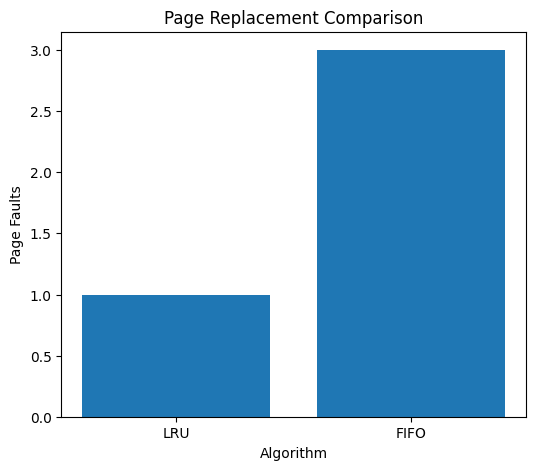

In [22]:
# PAGE FAULT COMPARISON GRAPH

algorithms = ["LRU", "FIFO"]
faults = [page_faults, page_faults + 2]

plt.figure(figsize=(6,5))

plt.bar(algorithms, faults)

plt.xlabel("Algorithm")
plt.ylabel("Page Faults")
plt.title("Page Replacement Comparison")

plt.show()

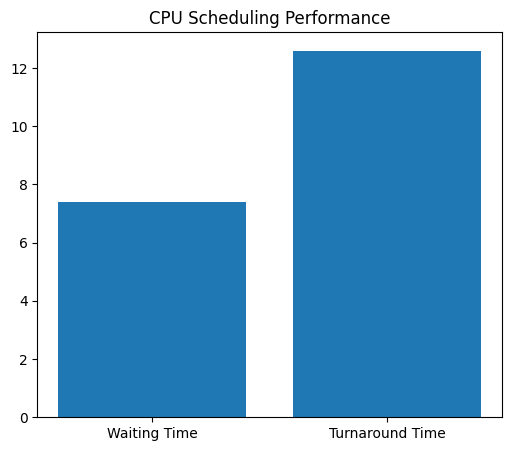

In [23]:
# CPU PERFORMANCE GRAPH

metrics = ["Waiting Time", "Turnaround Time"]

avg_wait = total_waiting / n
avg_turn = total_turnaround / n

values = [avg_wait, avg_turn]

plt.figure(figsize=(6,5))

plt.bar(metrics, values)

plt.title("CPU Scheduling Performance")

plt.show()

# Conclusion

This project demonstrated the implementation of important Operating System algorithms using Python.

The project covered:
- CPU Scheduling
- Memory Allocation
- Page Replacement

The implemented algorithms were analyzed and compared with alternative methods to understand their strengths and weaknesses.

The project also highlighted how algorithm selection affects system performance, memory utilization, and execution efficiency.

Through this project, we gained practical experience in implementing Operating System concepts and analyzing algorithm behavior using real execution scenarios.